In [ ]:
install.packages("ggplot2")
install.packages("dplyr")
install.packages("caTools")
install.packages("class")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘bitops’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(ggplot2)
library(dplyr)
library(caTools)
library(class)

dataset = read.csv('Advertisement.csv')
head(dataset)

,User.ID,Gender,Age,EstimatedSalary,Purchased
,<int>,<chr>,<int>,<int>,<int>
1,15624510,Male,19,19000,0
2,15810944,Male,35,20000,0
3,15668575,Female,26,43000,0
4,15603246,Female,27,57000,0
5,15804002,Male,19,76000,0
6,15728773,Male,27,58000,0


In [ ]:
set.seed(123)
split = sample.split(dataset$Purchased, SplitRatio = 0.75)
training_set = subset(dataset, split == TRUE)
test_set = subset(dataset, split == FALSE)

training_set[, c(3, 4)] = scale(training_set[, c(3, 4)])
test_set[, c(3, 4)] = scale(test_set[, c(3, 4)])

In [ ]:
y_pred = knn(train = training_set[,c(3,4)],  # Exclude User.ID, Gender, and Purchased columns
             test = test_set[, c(3,4)],
             cl = training_set[, 5],  # 'Purchased' as target variable
             k = 5,  # Number of nearest neighbors
             prob = TRUE)


In [ ]:
cm = table(test_set[, 5], y_pred)
cm

   y_pred
     0  1
  0 59  5
  1  6 30

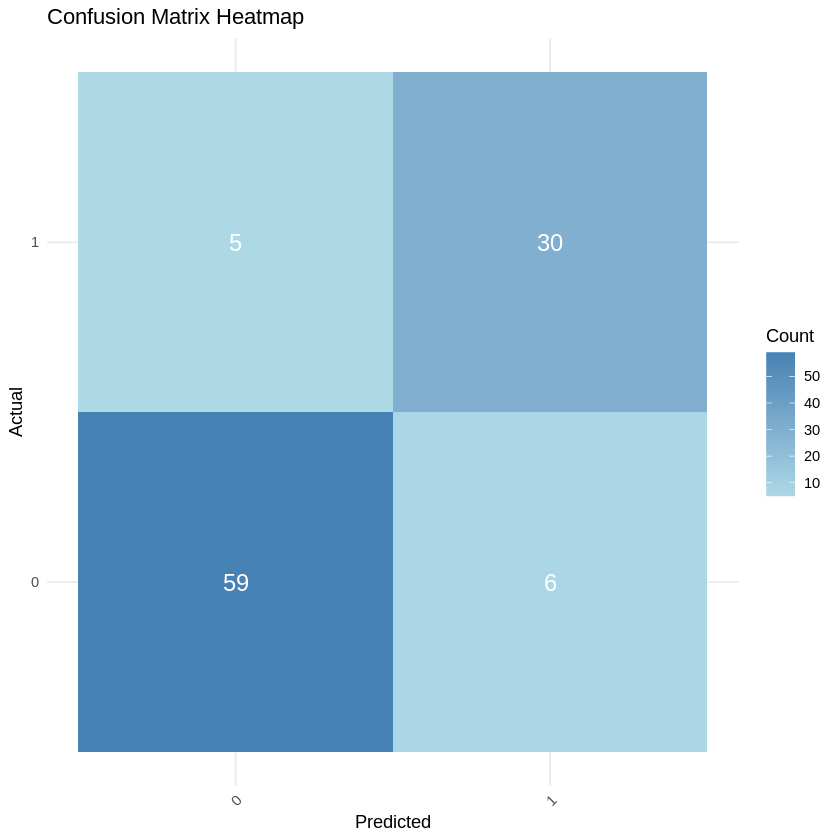

In [ ]:
# Convert the confusion matrix into a data frame for ggplot
cm_df <- as.data.frame(cm)
colnames(cm_df) <- c("Actual", "Predicted", "Count")

# Create the heatmap
ggplot(cm_df, aes(x = Actual, y = Predicted, fill = Count)) +
  geom_tile() +
  geom_text(aes(label = Count), color = "white", size = 5) +
  scale_fill_gradient(low = "lightblue", high = "steelblue") +
  theme_minimal() +
  labs(title = "Confusion Matrix Heatmap", x = "Predicted", y = "Actual") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  # Rotate x-axis labels for better readability

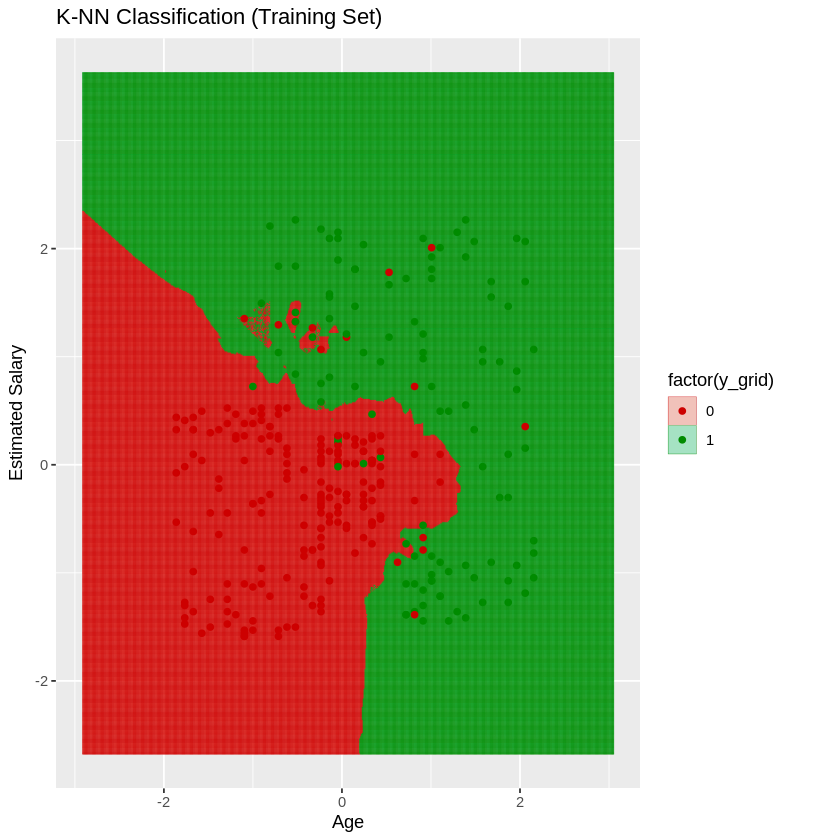

In [ ]:
set1 = training_set

# Create a grid of values for 'Age' and 'EstimatedSalary'
X1 = seq(min(set[, 3]) - 1, max(set[, 3]) + 1, by = 0.01)
X2 = seq(min(set[, 4]) - 1, max(set[, 4]) + 1, by = 0.01)
grid_set = expand.grid(X1, X2)

# Name the columns of the grid
colnames(grid_set) = c('Age', 'EstimatedSalary')

# Predicting the values and plotting them to grid
y_grid = knn(train = training_set[, 3:4], test = grid_set, cl = training_set[, 5], k = 5)

# Plotting the results with contour
ggplot(data = grid_set, aes(x = Age, y = EstimatedSalary, color = factor(y_grid))) +
  geom_tile(aes(fill = factor(y_grid)), alpha = 0.3) +
  geom_point(data = set1, aes(x = Age, y = EstimatedSalary, color = factor(Purchased))) +
  labs(title = "K-NN Classification (Training Set)", x = "Age", y = "Estimated Salary") +
  scale_fill_manual(values = c("tomato", "springgreen3")) +
  scale_color_manual(values = c("red3", "green4"))

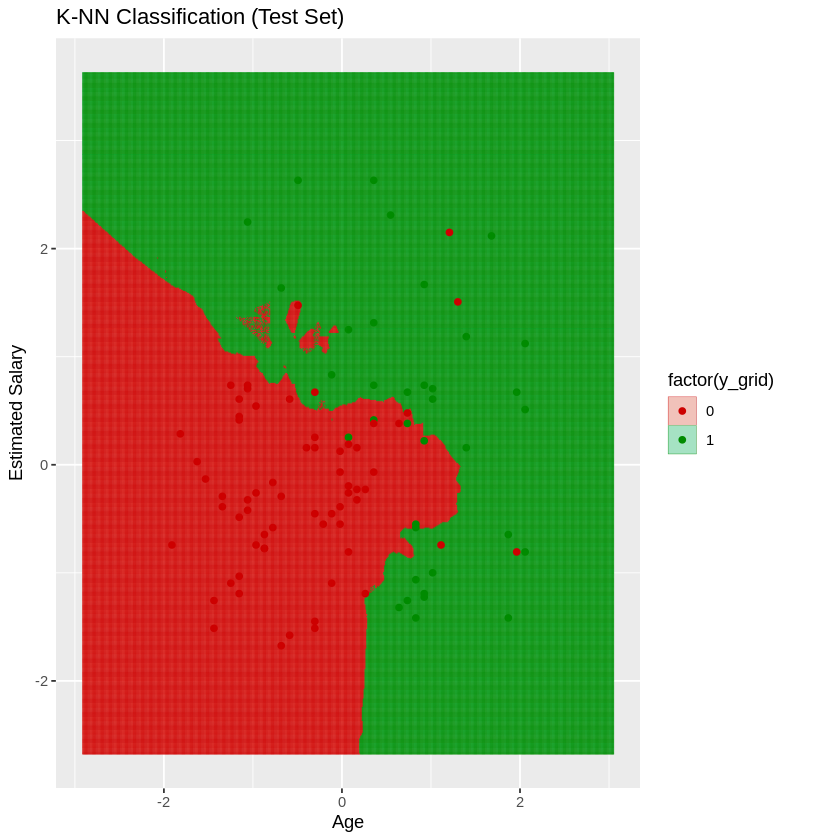

In [ ]:
# Visualizing the Test set results with contour plot
set2 = test_set

# Create a grid of values for 'Age' and 'EstimatedSalary'
X1 = seq(min(set[, 3]) - 1, max(set[, 3]) + 1, by = 0.01)
X2 = seq(min(set[, 4]) - 1, max(set[, 4]) + 1, by = 0.01)
grid_set = expand.grid(X1, X2)

# Name the columns of the grid
colnames(grid_set) = c('Age', 'EstimatedSalary')

# Predicting the values and plotting them to grid
y_grid = knn(train = training_set[, 3:4], test = grid_set, cl = training_set[, 5], k = 5)

# Plotting the results with contour
ggplot(data = grid_set, aes(x = Age, y = EstimatedSalary, color = factor(y_grid))) +
  geom_tile(aes(fill = factor(y_grid)), alpha = 0.3) +
  geom_point(data = set2, aes(x = Age, y = EstimatedSalary, color = factor(Purchased))) +
  labs(title = "K-NN Classification (Test Set)", x = "Age", y = "Estimated Salary") +
  scale_fill_manual(values = c("tomato", "springgreen3")) +
  scale_color_manual(values = c("red3", "green4"))

In [ ]:
install.packages("tidyverse")
install.packages("caret")
install.packages("datarium")

library(tidyverse)
library(caret)

data("marketing", package = "datarium")

head(marketing)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::la

,youtube,facebook,newspaper,sales
,<dbl>,<dbl>,<dbl>,<dbl>
1,276.12,45.36,83.04,26.52
2,53.40,47.16,54.12,12.48
3,20.64,55.08,83.16,11.16
4,181.80,49.56,70.20,22.20
5,216.96,12.96,70.08,15.48
6,10.44,58.68,90.00,8.64


In [ ]:
# Setting seed for reproducibility
set.seed(123)

# Splitting the data into training (80%) and testing (20%)
random_sample <- createDataPartition(marketing$sales, p = 0.8, list = FALSE)
training_dataset <- marketing[random_sample, ]
testing_dataset <- marketing[-random_sample, ]

# Building the linear regression model
model <- lm(sales ~ ., data = training_dataset)

# Predicting the target variable
predictions <- predict(model, testing_dataset)

# Computing model performance metrics
df= data.frame(
  R2 = R2(predictions, testing_dataset$sales),
  RMSE = RMSE(predictions, testing_dataset$sales),
  MAE = MAE(predictions, testing_dataset$sales)
)

df

R2,RMSE,MAE
<dbl>,<dbl>,<dbl>
0.9049049,1.965508,1.433609


In [ ]:
# Defining training control as LOOCV
train_control <- trainControl(method = "LOOCV")

# Training the model using LOOCV
model <- train(sales ~ ., data = marketing, method = "lm", trControl = train_control)

# Printing model performance metrics
print(model)


Linear Regression 

200 samples
  3 predictor

No pre-processing
Resampling: Leave-One-Out Cross-Validation 
Summary of sample sizes: 199, 199, 199, 199, 199, 199, ... 
Resampling results:

  RMSE      Rsquared   MAE     
  2.059984  0.8912074  1.539441

Tuning parameter 'intercept' was held constant at a value of TRUE


In [ ]:
# Defining training control as K-fold cross-validation (K=10)
train_control <- trainControl(method = "cv", number = 10)

# Training the model using K-fold cross-validation
model <- train(sales ~ ., data = marketing, method = "lm", trControl = train_control)

# Printing model performance metrics
print(model)


Linear Regression 

200 samples
  3 predictor

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 180, 180, 180, 179, 179, 180, ... 
Resampling results:

  RMSE      Rsquared   MAE     
  2.016416  0.8966065  1.545061

Tuning parameter 'intercept' was held constant at a value of TRUE


In [ ]:
# Defining training control as repeated K-fold cross-validation (K=10, repetitions=3)
train_control <- trainControl(method = "repeatedcv", number = 10, repeats = 3)

# Training the model using repeated K-fold cross-validation
model <- train(sales ~ ., data = marketing, method = "lm", trControl = train_control)

# Printing model performance metrics
print(model)


Linear Regression 

200 samples
  3 predictor

No pre-processing
Resampling: Cross-Validated (10 fold, repeated 3 times) 
Summary of sample sizes: 180, 180, 180, 180, 180, 180, ... 
Resampling results:

  RMSE      Rsquared  MAE   
  1.988418  0.900671  1.5236

Tuning parameter 'intercept' was held constant at a value of TRUE


In [ ]:
library(dplyr)
head(mtcars)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225,105,2.76,3.460,20.22,1,0,3,1


In [ ]:
# Finding the distance matrix
distance_mat <- dist(mtcars, method = 'euclidean')
distance_mat

                      Mazda RX4 Mazda RX4 Wag  Datsun 710 Hornet 4 Drive
Mazda RX4 Wag         0.6153251                                         
Datsun 710           54.9086059    54.8915169                           
Hornet 4 Drive       98.1125212    98.0958939 150.9935191               
Hornet Sportabout   210.3374396   210.3358546 265.0831615    121.0297564
Valiant              65.4717710    65.4392224 117.7547018     33.5508692
Duster 360          241.4076490   241.4088680 294.4790230    169.4299647
Merc 240D            50.1532711    50.1146059  49.6584796    121.2739722
Merc 230             25.4683117    25.3284509  33.1803843    118.2433145
Merc 280             15.3641921    15.2956865  66.9363534     91.4224033
Merc 280C            15.6724727    15.5837744  67.0261397     91.4612914
Merc 450SE          135.4307018   135.4254826 189.1954941     72.4964325
Merc 450SL          135.4014424   135.3960351 189.1631745     72.4313532
Merc 450SLC         135.4794674   135.4723157 189.2

In [ ]:
# Fitting the Hierarchical Clustering Model
set.seed(240)  # Setting seed for reproducibility
Hierar_cl <- hclust(distance_mat, method = "average")
Hierar_cl


Call:
hclust(d = distance_mat, method = "average")

Cluster method   : average 
Distance         : euclidean 
Number of objects: 32 


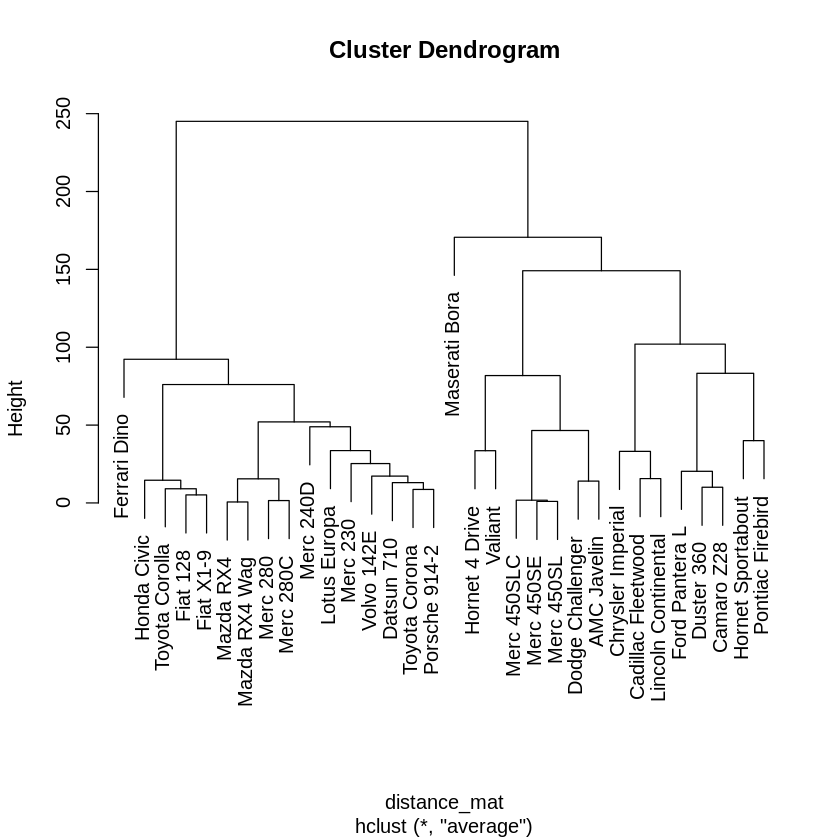

In [ ]:
# Plotting the dendrogram
plot(Hierar_cl)


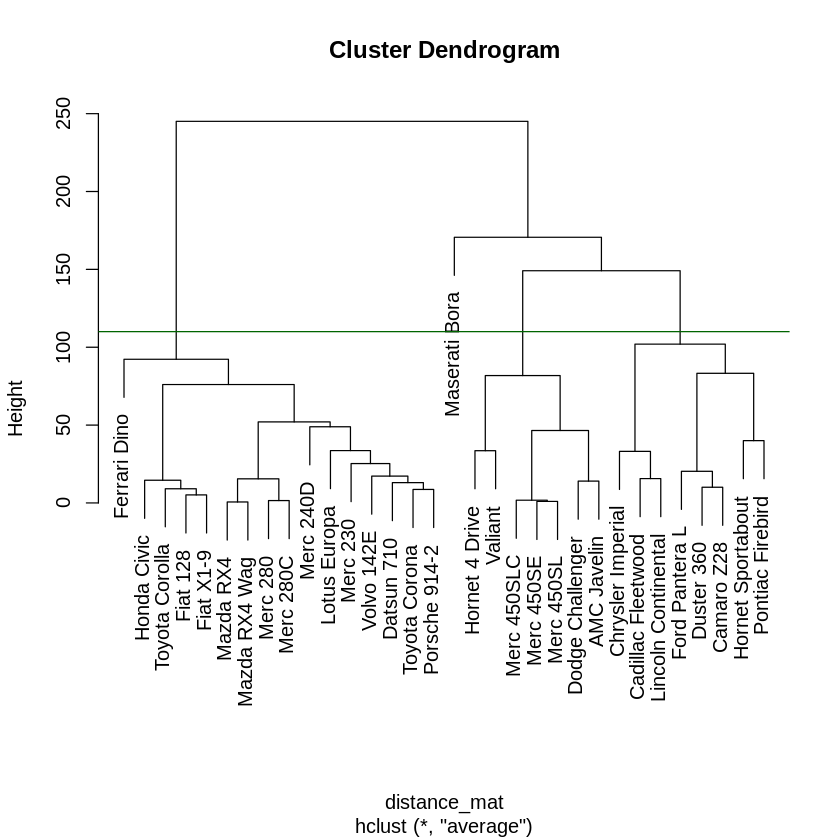

In [ ]:
# Plotting the dendrogram
plot(Hierar_cl)

# Adding a horizontal line at height 110
abline(h = 110, col = "darkgreen")

# Cutting the tree into 3 clusters
fit <- cutree(Hierar_cl, k = 3)


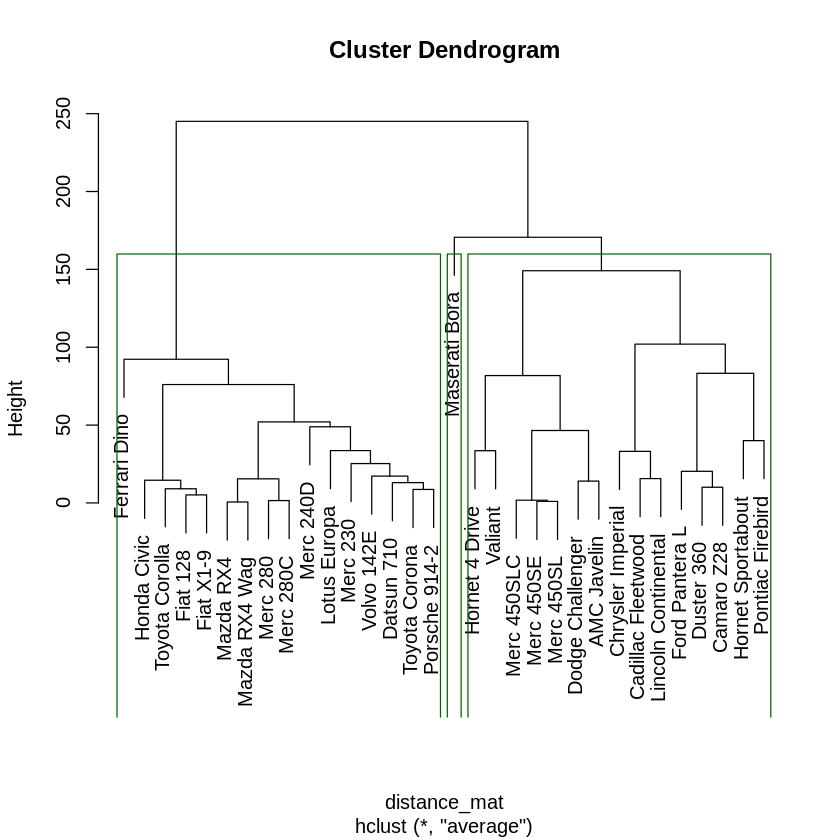

In [ ]:
plot(Hierar_cl)
rect.hclust(Hierar_cl, k = 3, border = "darkgreen")  # Drawing rectangles around clusters